In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import pickle
import os
import warnings

from i import input_dir, output_dir, model_dir
from kaggle_modules import Features

from scipy.optimize import nnls
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.utils import set_random_seed
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Disable warnings
warnings.filterwarnings("ignore")

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)

train = pd.read_csv(input_dir + "train.csv", index_col=0)
test = pd.read_csv(input_dir + "test.csv", index_col=0)

for col in train.select_dtypes(include="object").columns:
    train[col] = train[col].astype("category")
    test[col] = test[col].astype("category")

TARGET_COL = "exam_score"
y = train[TARGET_COL]
X = train.drop(columns=TARGET_COL)
X_pred = test


In [2]:
X_inspection = Features().fit_transform(X, y)

In [3]:
categorical_cols = X.select_dtypes(include="category").columns.tolist()
numeric_cols = X.select_dtypes(exclude="category").columns.tolist()

# Sparse View: numerics + one-hot for categoricals
SparseView = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

In [4]:
class LinearThenPoly(BaseEstimator, TransformerMixin):
    def __init__(self, degree=2, interaction_only=True):
        self.degree = degree
        self.interaction_only = interaction_only
        self.linear_features_ = None
        self.poly_ = PolynomialFeatures(
            degree=self.degree,
            interaction_only=self.interaction_only,
            include_bias=False,
        )

    def fit(self, X, y=None):
        # First transform with linear Features
        linear = Features(model="linear")
        linear.fit(X, y)
        X_lin = linear.transform(X)
        self.linear_features_ = linear
        self.poly_.fit(X_lin)
        return self

    def transform(self, X):
        X_lin = self.linear_features_.transform(X)
        X_poly = self.poly_.transform(X_lin)
        return X_poly

In [5]:
class CatBoostWrapper(BaseEstimator):
    def __init__(self, **params):
        self.params = params
        self.model = None

    def fit(self, X, y):
        cat_idx = list(range(X.shape[1]))  # all columns are categorical strings
        self.model = CatBoostRegressor(**self.params, cat_features=cat_idx, verbose=False)
        self.model.fit(X, y)
        self.is_fitted_ = True
        return self

    def predict(self, X):
        return self.model.predict(X)
    
    def get_feature_importance(self, prettified=True):
        return self.model.get_feature_importance(prettified=prettified)

In [6]:
class KerasLinear(BaseEstimator):
    """
    Neural network base learner for the LINEAR view.
    ✔ Works with Features(model="linear")
    ✔ Automatically scales numeric inputs
    ✔ OOF safe (no leakage)
    ✔ predict_proba() returns 2-cols like sklearn
    """

    def __init__(
        self,
        hidden_units=128,
        dropout=0.20,
        lr=1e-3,
        batch_size=256,
        epochs=200,
        random_state=42,
    ):
        self.hidden_units = hidden_units
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.random_state = random_state

        self.scaler = StandardScaler()
        self.model = None

    def _build_model(self, input_dim):
        model = Sequential(
            [
                Input(shape=(input_dim,)),
                Dense(self.hidden_units, activation="relu"),
                BatchNormalization(),
                Dropout(self.dropout),
                Dense(self.hidden_units, activation="relu"),
                BatchNormalization(),
                Dropout(self.dropout),
                Dense(self.hidden_units // 2, activation="relu"),
                BatchNormalization(),
                Dropout(self.dropout),
                Dense(self.hidden_units // 2, activation="relu"),
                BatchNormalization(),
                Dropout(self.dropout),
                Dense(1, activation="linear"),
            ]
        )

        model.compile(loss="mse", optimizer=Adam(self.lr), metrics=[RootMeanSquaredError()])
        return model

    def fit(self, X, y):
        set_random_seed(self.random_state)

        X_scaled = self.scaler.fit_transform(X)

        self.model = self._build_model(X_scaled.shape[1])

        callbacks = [
            EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=0),
        ]

        self.model.fit(
            X_scaled,
            y,
            validation_split=0.15,
            batch_size=self.batch_size,
            epochs=self.epochs,
            verbose=0,
            callbacks=callbacks,
        )

        self.is_fitted_ = True
        return self

    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled, verbose=0).reshape(-1)

In [7]:
def pipeline_hash(pipeline):
    params = pipeline.get_params(deep=False)

    safe = {}
    for k, v in params.items():
        if isinstance(v, (int, float, str, bool, tuple)):
            safe[k] = v
        else:
            # Only keep the CLASS NAME, not the object
            safe[k] = v.__class__.__name__

    return hashlib.md5(pickle.dumps(safe)).hexdigest()

In [8]:
def fit_with_oof_cached(name, pipeline, X, y, cv, cache_dir=model_dir):
    """
    Train model sequentially with OOF predictions.
    Uses caching: loads saved results when hash matches.
    """

    # Create directory for this model
    new_model_dir = os.path.join(cache_dir, name)
    os.makedirs(new_model_dir, exist_ok=True)

    # Compute hash
    current_hash = pipeline_hash(pipeline)
    hash_path = os.path.join(new_model_dir, "hash.txt")
    oof_path = os.path.join(new_model_dir, "oof.npy")
    model_path = os.path.join(new_model_dir, "model.pkl")

    if os.path.exists(hash_path) and os.path.exists(oof_path) and os.path.exists(model_path):
        saved_hash = open(hash_path).read().strip()

        if saved_hash == current_hash:
            print(f"\n[LOAD] {name}: Cached model found. Skipping training.")
            oof = np.load(oof_path)
            final_model = pickle.load(open(model_path, "rb"))
            return oof, final_model

        else:
            print(f"\n[INFO] {name}: Pipeline changed → retraining.")
    else:
        print(f"\n[TRAIN] {name}: No cache → training model.")

    oof = np.zeros(len(X))

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
        print(f"{name} – Fold {fold + 1}/{cv.n_splits}")

        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = clone(pipeline)
        model.fit(X_tr, y_tr)
        oof[val_idx] = model.predict(X_val)

    # Train final on full data
    final_model = clone(pipeline)
    final_model.fit(X, y)

    np.save(oof_path, oof)
    pickle.dump(final_model, open(model_path, "wb"))
    open(hash_path, "w").write(current_hash)

    print(f"[SAVED] {name}: Model + OOF cached.\n")

    return oof, final_model


In [9]:
def train_all_cached(base_models, X, y, cv):
    oof_dict = {}
    final_dict = {}

    for name, pipe in base_models.items():
        oof, final_model = fit_with_oof_cached(name, pipe, X, y, cv)
        oof_dict[name] = oof
        final_dict[name] = final_model

    print("\nAll models trained (cached when possible).")
    return oof_dict, final_dict


In [10]:
# Base View: Features() -> XGB
xgb_base = Pipeline(
    [
        ("features", Features()),
        (
            "model",
            XGBRegressor(
                random_state=42,
                booster="dart",
                n_estimators=2500,
                learning_rate=0.03,
                max_depth=7,
                subsample=0.8,
                colsample_bytree=0.8,
                enable_categorical=True,
                device="gpu",
                n_jobs=7,
            ),
        ),
    ]
)

# Interaction View: Linear -> Poly -> XGB
xgb_inter = Pipeline(
    [
        ("features_poly", LinearThenPoly(degree=2, interaction_only=True)),
        (
            "model",
            XGBRegressor(
                random_state=42,
                n_estimators=2000,
                learning_rate=0.03,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                enable_categorical=True,
                tree_method="hist",
                device="gpu",
                n_jobs=7,
            ),
        ),
    ]
)

cat_default = Pipeline(
    [
        ("features", Features(model="category")),
        (
            "model",
            CatBoostWrapper(
                random_state=42,
                n_estimators=1500,
                learning_rate=0.05,
                depth=8,
                thread_count=7,
            ),
        ),
    ]
)

# Linear View: Features(linear) -> HistGB
hgb_linear = Pipeline(
    [
        ("features", Features(model="linear")),
        (
            "model",
            HistGradientBoostingRegressor(
                max_depth=6,
                learning_rate=0.05,
                max_iter=700,
                random_state=42,
                l2_regularization=1.0,
            ),
        ),
    ]
)

# Linear View: Features(linear) -> LogisticRegression
lr_linear = Pipeline(
    [
        ("features", Features(model="linear")),
        (
            "model",
            ElasticNet(
                # solver="sage",
                max_iter=3000,
            ),
        ),
    ]
)

# Sparse View: ColumnTransformer (OHE) -> LogisticRegression (L1)
lr_sparse = Pipeline(
    [
        ("sparse", SparseView),
        (
            "model",
            Ridge(
                solver="saga",
                max_iter=3000,
            ),
        ),
    ]
)

# linear View: Features() -> ExtraTrees (robust bagging)
et_base = Pipeline(
    [
        ("features", Features(model="linear")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=1000,
                max_depth=None,
                min_samples_split=4,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=7,
            ),
        ),
    ]
)

keras_linear = Pipeline(
    [
        ("features", Features(model="linear")),
        (
            "keras",
            KerasLinear(
                hidden_units=128,
                dropout=0.1,
                lr=1e-3,
                batch_size=256,
                epochs=300,
            ),
        ),
    ]
)

cat_linear = Pipeline(
    [
        ("features", Features(model="linear")),
        (
            "model",
            CatBoostWrapper(
                depth=6,
                learning_rate=0.03,
                n_estimators=2000,
                l2_leaf_reg=3.0,
                thread_count=7,
                random_state=42,
                verbose=False,
            ),
        ),
    ]
)

lgb_base = Pipeline(
    [
        ("features", Features()),
        (
            "model",
            LGBMRegressor(
                n_estimators=2500,
                learning_rate=0.03,
                num_leaves=64,
                subsample=0.7,
                colsample_bytree=0.7,
                reg_alpha=2,
                reg_lambda=2,
                categorical_feature="auto",
                random_state=42,
                n_jobs=7,
                verbose=-1,
            ),
        ),
    ]
)

base_models = {
    "xgb_base": xgb_base,
    "lgb_base": lgb_base,
    "xgb_inter": xgb_inter,
    "cat_default": cat_default,
    "hgb_linear": hgb_linear,
    "lr_linear": lr_linear,
    "lr_sparse": lr_sparse,
    "et_base": et_base,
    "keras_linear": keras_linear,
    # "cat_linear": cat_linear,
}


[LOAD] xgb_base: Cached model found. Skipping training.

[LOAD] lgb_base: Cached model found. Skipping training.

[LOAD] xgb_inter: Cached model found. Skipping training.

[LOAD] cat_default: Cached model found. Skipping training.

[LOAD] hgb_linear: Cached model found. Skipping training.

[LOAD] lr_linear: Cached model found. Skipping training.

[LOAD] lr_sparse: Cached model found. Skipping training.

[LOAD] et_base: Cached model found. Skipping training.

[LOAD] keras_linear: Cached model found. Skipping training.

All models trained (cached when possible).

All base models trained successfully.


Base model performance (OOF RMSE & Accuracy):
xgb_base     - RMSE: 8.77033
lgb_base     - RMSE: 8.75496
xgb_inter    - RMSE: 8.75532
cat_default  - RMSE: 9.30573
hgb_linear   - RMSE: 8.77008
lr_linear    - RMSE: 9.02591
lr_sparse    - RMSE: 8.89482
et_base      - RMSE: 9.09027
keras_linear - RMSE: 8.86256


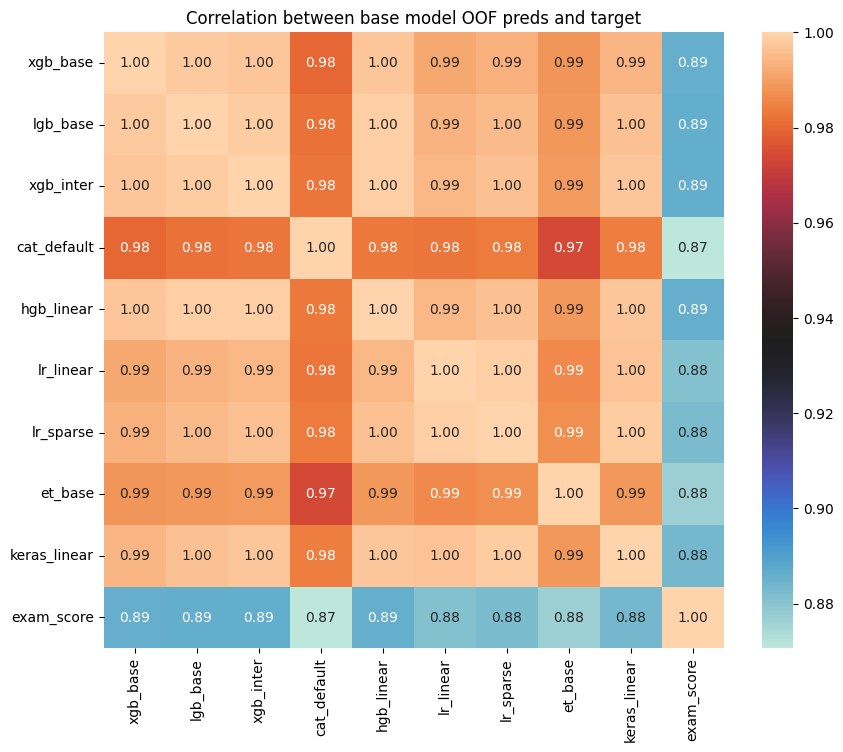

In [11]:
oof_dict, final_models = train_all_cached(base_models, X, y, cv)

print("\nAll base models trained successfully.\n")

# Level-1 OOF matrix
predictionMatrix = pd.DataFrame(oof_dict, index=X.index)

print("\nBase model performance (OOF RMSE & Accuracy):")
for name in predictionMatrix.columns:
    rmse = root_mean_squared_error(y, predictionMatrix[name])
    
    print(f"{name:12} - RMSE: {rmse:.5f}")

plt.figure(figsize=(10, 8))
sns.heatmap(
    data=pd.concat([predictionMatrix, y.rename(TARGET_COL)], axis=1).corr().abs(),
    cmap="icefire",
    annot=True,
    fmt=".2f",
)
plt.title("Correlation between base model OOF preds and target")
plt.show()

In [12]:
# Meta model 1: Logistic Regression
meta_lr = ElasticNet(
    random_state=42,
    l1_ratio=0.3,
)
lr_trans = Features(model="linear")
lr_pred_matrix = pd.concat([lr_trans.fit_transform(X,y), predictionMatrix], axis=1)

meta_lr.fit(predictionMatrix, y)
meta_lr_oof = meta_lr.predict(predictionMatrix)
meta_lr_auc = root_mean_squared_error(y, meta_lr_oof)
print(f"\nMETA_LR  - RMSE: {meta_lr_auc:.5f}")

# Meta model 2: XGB on OOF predictions
meta_xgb = XGBRegressor(
    random_state=42,
    n_estimators=800,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.9,
    enable_categorical=True,
    tree_method="hist",
    device="gpu",
    n_jobs=7,
)
weights, _ = nnls(predictionMatrix.values, y)
w = weights / weights.sum()

meta_xgb.fit(lr_pred_matrix, y)
meta_xgb_oof = meta_xgb.predict(lr_pred_matrix)
meta_xgb_auc =root_mean_squared_error(y, meta_xgb_oof)
print(f"META_XGB - RMSE: {meta_xgb_auc:.5f}")

# Simple blender on train: average of meta models
meta_blend_oof = (predictionMatrix.values * w).sum(axis=1)
meta_blend_auc = root_mean_squared_error(y, meta_blend_oof)

print(f"BLEND    - RMSE: {meta_blend_auc:.5f}")


META_LR  - RMSE: 8.73718
META_XGB - RMSE: 8.71005
BLEND    - RMSE: 8.73658


In [13]:
# Level-1 predictions on test
PredProbMatrix = pd.DataFrame(
    {name: model.predict(X_pred) for name, model in final_models.items()},
    index=X_pred.index,
)

lr_pred_Prob_matrix = pd.concat([lr_trans.transform(X_pred), PredProbMatrix], axis=1)


# Level-2 predictions on test
meta_lr_test = meta_lr.predict(PredProbMatrix)
meta_xgb_test = meta_xgb.predict(lr_pred_Prob_matrix)
meta_blend_test = (PredProbMatrix.values * w).sum(axis=1)

# Final submission (you can also submit meta_lr_test or meta_xgb_test separately)
submission = pd.DataFrame(
    {TARGET_COL: meta_blend_test},
    index=X_pred.index,
)
submission.to_csv(output_dir + "submission.csv")

submission_xgb = pd.DataFrame(
    {TARGET_COL: meta_xgb_test},
    index=X_pred.index,
)
submission_xgb.to_csv(output_dir + "submission_elite_stack_xgb.csv")

submission_lr = pd.DataFrame(
    {TARGET_COL: meta_lr_test},
    index=X_pred.index,
)
submission_lr.to_csv(output_dir + "submission_elite_stack_lr.csv")
print("\nSaved submission to:", output_dir + "submission.csv")


Saved submission to: C:/Users/Blanc/DataScientist/Kaggle/PlayGround/S6E01/output/submission.csv


1. BASE MODEL OOF PERFORMANCE

                   AUC
cat_default   9.305727
et_base       9.090270
lr_linear     9.025909
lr_sparse     8.894822
keras_linear  8.862563
xgb_base      8.770328
hgb_linear    8.770084
xgb_inter     8.755317
lgb_base      8.754959 

2. CORRELATION BETWEEN BASE MODELS



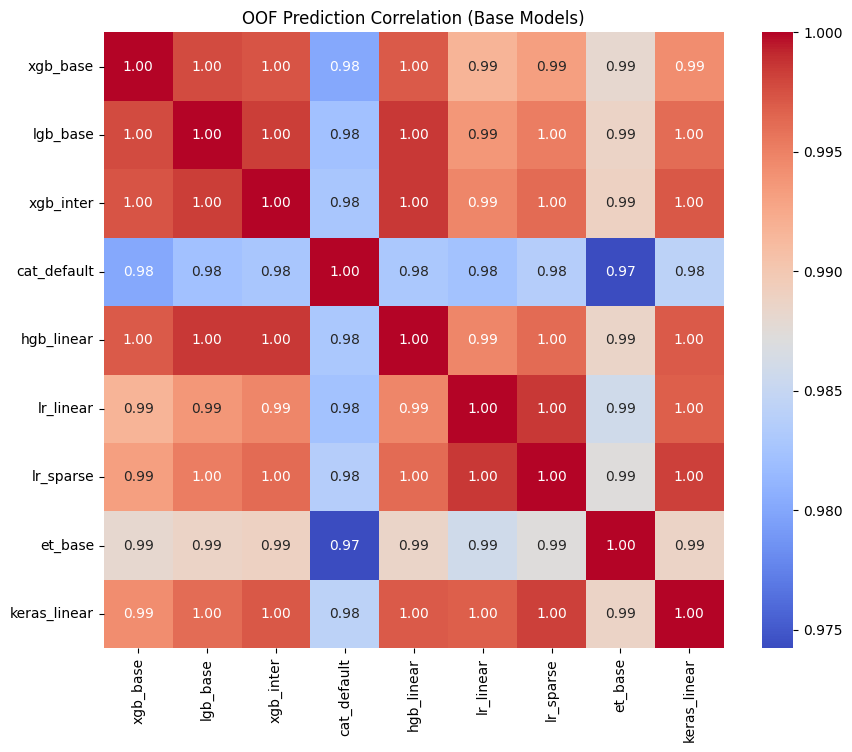


Lower correlation = better stacking diversity.

3. MUTUAL INFORMATION WITH TARGET



ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [14]:
print("1. BASE MODEL OOF PERFORMANCE\n")
auc_scores = {name: root_mean_squared_error(y, predictionMatrix[name]) for name in predictionMatrix.columns}
auc_df = pd.DataFrame.from_dict(auc_scores, orient="index", columns=["AUC"])
auc_df = auc_df.sort_values("AUC", ascending=False)
print(auc_df, "\n")


print("2. CORRELATION BETWEEN BASE MODELS\n")

plt.figure(figsize=(10, 8))
sns.heatmap(predictionMatrix.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("OOF Prediction Correlation (Base Models)")
plt.show()

print("\nLower correlation = better stacking diversity.\n")


print("3. MUTUAL INFORMATION WITH TARGET\n")

mi_scores = mutual_info_classif(predictionMatrix, y, discrete_features=False, random_state=42)

mi_df = pd.DataFrame(mi_scores, index=predictionMatrix.columns, columns=["MutualInformation"]).sort_values("MutualInformation", ascending=False)

print(mi_df, "\n")



print("4. MARGINAL CONTRIBUTION OF EACH MODEL (DROP TEST)\n")


def stack_auc(models):
    meta_temp = Ridge(max_iter=2000, solver="saga")
    meta_temp.fit(predictionMatrix[models], y)
    return Ridge(y, meta_temp.predict(predictionMatrix[models]))


base_models_list = list(predictionMatrix.columns)
full_auc = stack_auc(base_models_list)

drop_results = {}
for m in base_models_list:
    reduced = [x for x in base_models_list if x != m]
    auc_drop = stack_auc(reduced)
    drop_results[m] = full_auc - auc_drop  # positive = helpful

drop_df = pd.DataFrame.from_dict(drop_results, orient="index", columns=["MarginalContribution"]).sort_values("MarginalContribution", ascending=False)

print(drop_df, "\n")
print("Interpretation: High-positive means the model is valuable.\n")


print("5. STACKING GAIN OVER BEST SINGLE MODEL\n")

best_single = auc_df.iloc[0]["AUC"]
gain = meta_blend_auc - best_single
print(f"Best single model: {best_single:.5f}")
print(f"Stack (blend) AUC: {meta_blend_auc:.5f}")
print(f"Gain from stacking: {gain:.5f}\n")


print("6. OPTIMAL BLENDING WEIGHTS (NNLS)\n")


X_mat = predictionMatrix.values
y_vec = y.values

weights, _ = nnls(X_mat, y_vec)

blend_df = pd.DataFrame(weights / weights.sum(), index=predictionMatrix.columns, columns=["OptimalWeight"]).sort_values(
    "OptimalWeight", ascending=False
)

print(blend_df, "\n")


print("7. VIEW EFFECTIVENESS\n")

view_map = {
    "xgb_base": "BaseView",
    "xgb_inter": "InteractionView",
    "cat_default": "CatView",
    "hgb_linear": "LinearView",
    "lr_linear": "LinearView",
    "lr_sparse": "SparseView",
    "et_base": "BaseView",
    "keras_linear": "LinearView",
}

# Use the AUCs you already computed above
view_df = pd.DataFrame({
    "model": predictionMatrix.columns,
    "view": predictionMatrix.columns.map(lambda c: view_map.get(c, "Unknown")),
    "AUC": [auc_scores[m] for m in predictionMatrix.columns],
})

print(view_df, "\n")
print("Mean AUC per view:\n", view_df.groupby("view")["AUC"].mean(), "\n")



print("8. MODEL DIVERSITY SCORE (1 - |correlation| means diversity)\n")

corr = predictionMatrix.corr().abs()
diversity = 1 - corr
np.fill_diagonal(diversity.values, np.nan)

div_df = pd.DataFrame(diversity.mean(), columns=["DiversityScore"]).sort_values("DiversityScore", ascending=False)

print(div_df, "\n")
print("Higher score = more diverse = better stacking synergy.\n")

